# Notebook 02: Green's Function Elasticity Solver

Computes 2D elastic strain and stress fields induced by defect eigenstrains
in an isotropic linear elastic medium under plane strain.

**Method:** The equilibrium equations are solved in Fourier space using the
isotropic Green's function tensor. For a prescribed eigenstrain field
$\varepsilon^*_{ij}$, the displacement in Fourier space is:

$$\tilde{u}_i(\mathbf{k}) = G_{ij}(\mathbf{k})\,\tilde{\varepsilon}^*_{jk}(\mathbf{k})$$

Real-space strains are recovered via inverse FFT and Sobel finite differences.
Stresses follow from $\sigma_{ij} = \lambda\delta_{ij}\varepsilon_{kk} + 2\mu\varepsilon_{ij}$.

**Input:** Eigenstrain values from `eigenstrain_results.csv` (Notebook 01).  
**Output:** Strain field decomposition figure for five defect configurations in STO.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
sys.path.append("../src")
from elasticity_utils import build_greens_function, generate_inclusion_mask, compute_strain_and_energy

plt.rcParams["font.family"] = "Helvetica"
plt.rcParams.update({"mathtext.default": "regular"})

# --- Parameters ---
GRID_SIZE = 128
INCLUSION_RADIUS = 12
MU, NU = 1.0, 0.25

# --- Build Green's function once ---
Gxx, Gxy, Gyy = build_greens_function(GRID_SIZE, MU, NU)

In [2]:
df = pd.read_csv("../data/eigenstrain_results.csv")

selected_defects = [
    "Fe_Ti_V_O_0_3_+U",
    "2Fe_Ti_V_O_0_3_+U",
    "Fe_Ti_0_3_+U",
    "VO_0_3_+U",
    "2Fe_Ti_0_3_+U"
]
titles = [
    r"Fe$_\mathrm{Ti}$ + V$_\mathrm{O}$",
    r"2Fe$_\mathrm{Ti}$ + V$_\mathrm{O}$",
    r"Fe$_\mathrm{Ti}$",
    r"V$_\mathrm{O}$",
    r"2Fe$_\mathrm{Ti}$"
]

# Extract eigenstrain tuples for each defect
eigenstrains = []
for defect in selected_defects:
    row = df[df["defect"] == defect].iloc[0]
    eigenstrains.append((row["strain_xx"], row["strain_yy"], row["strain_xy"]))

In [3]:
center = (GRID_SIZE // 2, GRID_SIZE // 2)

strain_fields = []  # list of strain dicts, one per defect
for eigenstrain in eigenstrains:
    exx, eyy, exy = generate_inclusion_mask([center], GRID_SIZE, INCLUSION_RADIUS, eigenstrain)
    strain, stress, energy_density, total_energy, _ = compute_strain_and_energy(
        exx, eyy, exy, Gxx, Gxy, Gyy, MU, NU
    )
    strain_fields.append(strain)

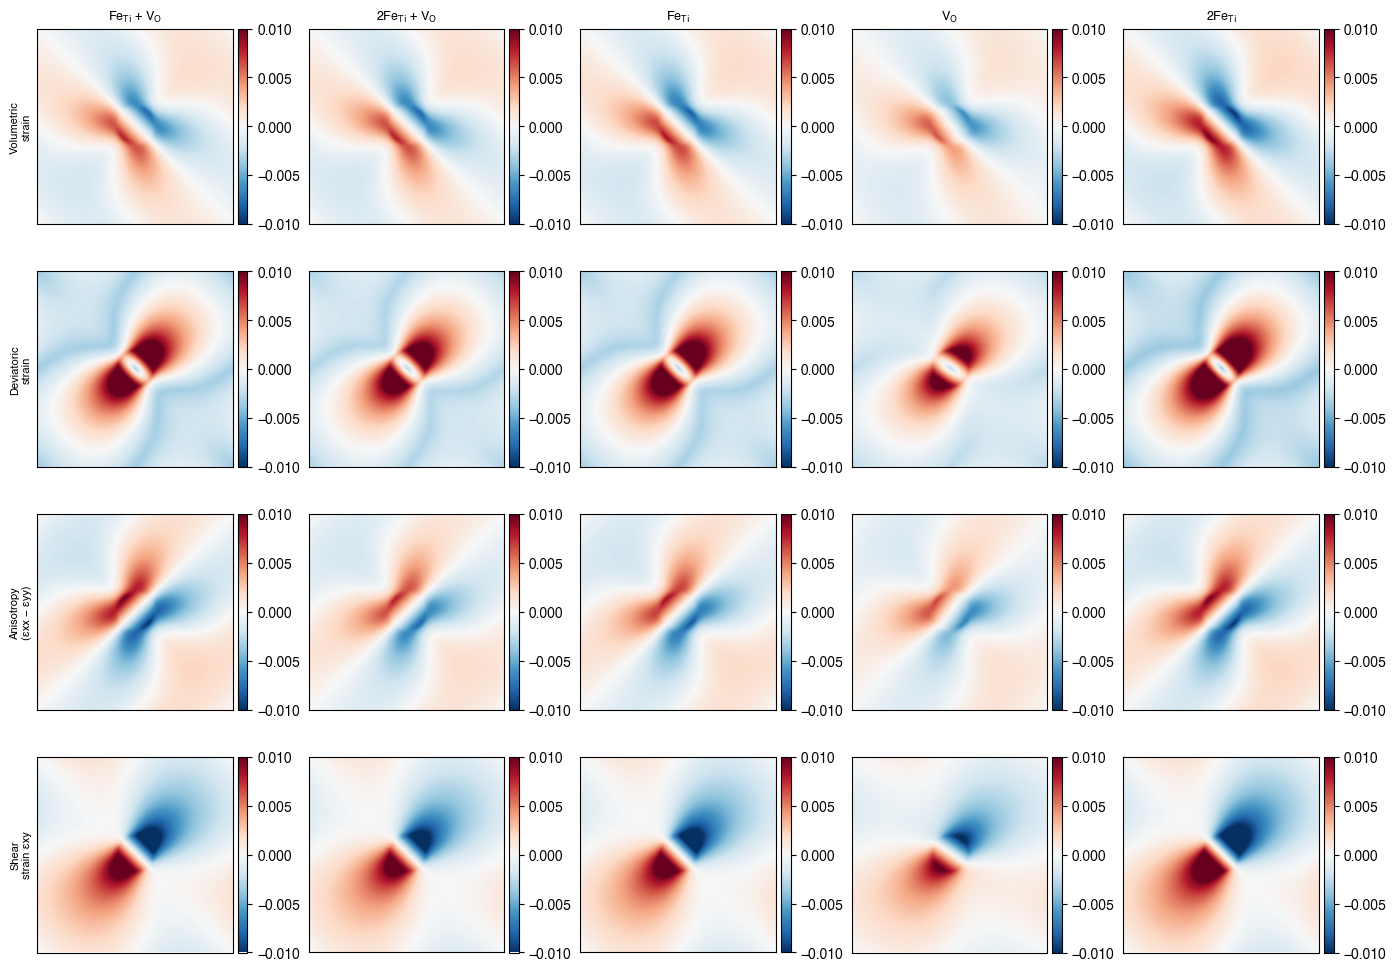

In [5]:
row_labels = ["Volumetric\nstrain", "Deviatoric\nstrain", "Anisotropy\n(εxx − εyy)", "Shear\nstrain εxy"]

def compute_derived_fields(s):
    """Compute scalar strain metrics from strain dict."""
    volumetric  = s['xx'] + s['yy']
    deviatoric  = np.sqrt(0.5 * ((s['xx'] - s['yy'])**2 + 4 * s['xy']**2))
    anisotropy  = s['xx'] - s['yy']
    shear       = s['xy']
    return [volumetric, deviatoric, anisotropy, shear]

fig, axes = plt.subplots(4, 5, figsize=(14, 10))
vmax = 0.01

for col, (strain, title) in enumerate(zip(strain_fields, titles)):
    derived = compute_derived_fields(strain)
    for row, field in enumerate(derived):
        ax = axes[row, col]
        field_centered = field - field.mean()
        im = ax.imshow(field_centered, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       origin="lower", interpolation="bilinear")
        ax.set_xticks([])
        ax.set_yticks([])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax)
        if row == 0:
            ax.set_title(title, fontsize=9)
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=8, labelpad=4)

plt.tight_layout()
plt.savefig("../figures/strain_field_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()